# Shanghai observed mobility: motif diversity and regularity

This notebook classifies every classifiable observed user-day with fastmob. It intentionally omits motif-prevalence plots and focuses on how many different daily motifs people use and whether their motif signatures are stable on weekdays versus weekends.

In [1]:
from pathlib import Path
import sys

import seaborn as sns
from IPython.display import display

PROJECT_ROOT = next(
    candidate for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (candidate / 'pyproject.toml').exists()
)
for path in [PROJECT_ROOT, PROJECT_ROOT / 'notebooks']:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from motif_analysis_utils import (
    classify_observed_daily_motifs, motif_diversity_and_regularity,
    plot_motif_diversity, plot_weekday_weekend_regularity,
)

sns.set_theme(style='whitegrid', context='notebook')
OBSERVED_PATH = PROJECT_ROOT / 'data' / 'shanghai' / 'shanghai_data_raw.parquet'
assert OBSERVED_PATH.exists(), OBSERVED_PATH
print(f'Observed input: {OBSERVED_PATH}')

Observed input: /home/gustavo/citybehavex/data/shanghai/shanghai_data_raw.parquet


In [2]:
analysis = classify_observed_daily_motifs(
    OBSERVED_PATH, uid_col='user_id', timestamp_col='timestamp',
    location_col='venueId', lat_col='lat', lng_col='long',
)
daily = analysis['daily']
display(analysis['coverage'])
print(analysis['purpose_heuristic_warning'])
if not analysis['skipped_user_days'].empty:
    display(analysis['skipped_user_days'])

,metric,value
0,source observations,10552587
1,people,58502
2,input user-days,584991
3,classified user-days,584991
4,skipped user-days,0
5,first date,2015-12-27
6,last date,2016-01-05


shanghai_data_raw has no explicit purpose column; derived HOME/WORK/OTHER with time-of-day and repeated-location heuristics.


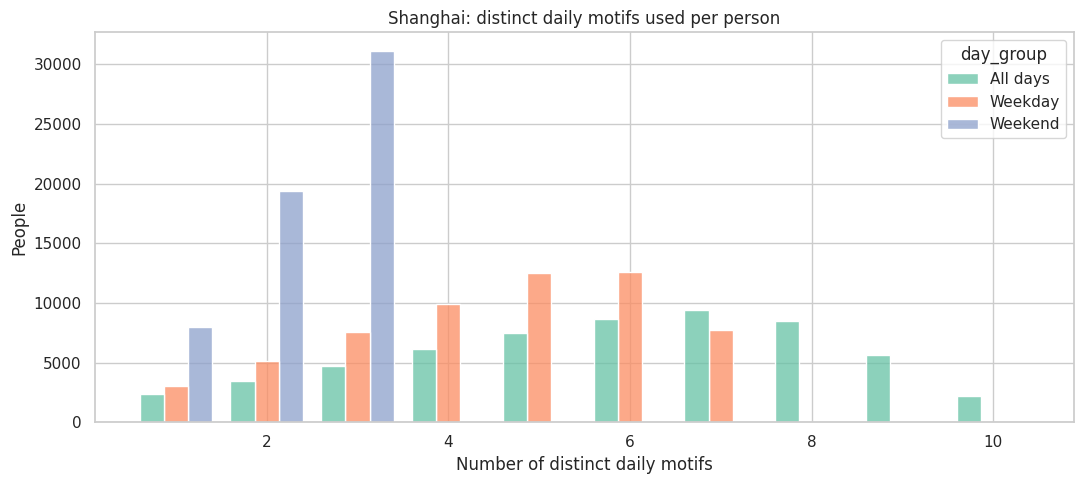

,count,mean,std,min,25%,50%,75%,max
day_group,,,,,,,,
All days,58502.0,5.88,2.33,1.0,4.0,6.0,8.0,10.0
Weekday,58502.0,4.58,1.70,1.0,3.0,5.0,6.0,7.0
Weekend,58502.0,2.40,0.72,1.0,2.0,3.0,3.0,3.0


In [3]:
summaries = motif_diversity_and_regularity(daily)
plot_motif_diversity(summaries['diversity'], 'Shanghai: distinct daily motifs used per person')
display(summaries['diversity'].groupby('day_group', observed=True)['distinct_motifs'].describe().round(2))

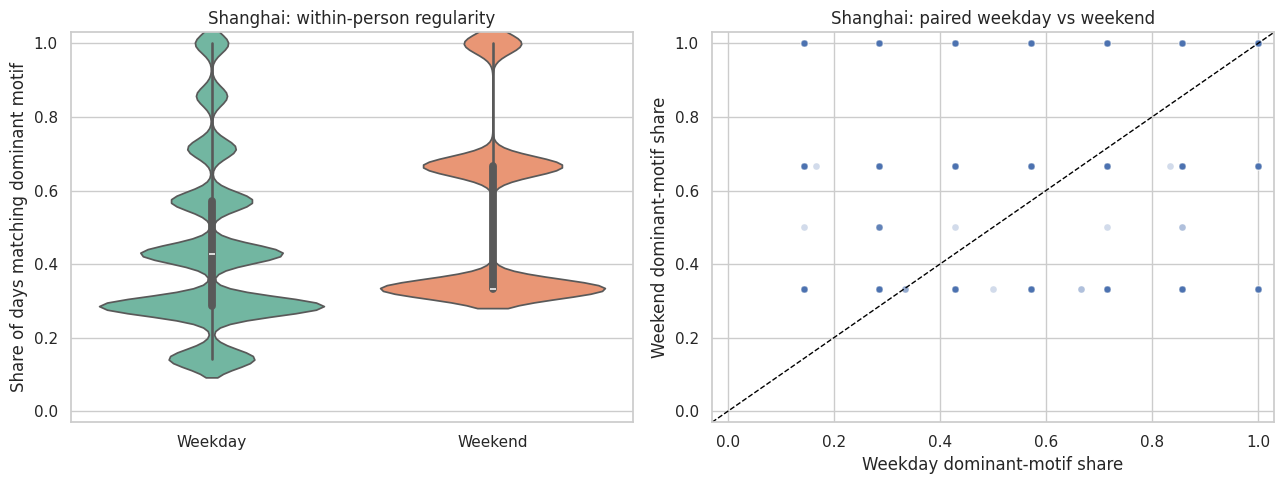

People eligible for paired comparison: 58,502
Mean weekday regularity: 43.1%
Mean weekend regularity: 53.5%
Mean weekend minus weekday difference: +10.4%


In [4]:
plot_weekday_weekend_regularity(
    summaries['regularity_long'], summaries['paired_regularity'], 'Shanghai'
)
paired = summaries['paired_regularity']
print(f'People eligible for paired comparison: {len(paired):,}')
print(f'Mean weekday regularity: {paired["Weekday"].mean():.1%}')
print(f'Mean weekend regularity: {paired["Weekend"].mean():.1%}')
print(f'Mean weekend minus weekday difference: {(paired["Weekend"] - paired["Weekday"]).mean():+.1%}')

## Reading the results

Diversity is the number of canonical daily mobility graphs a person exhibits across their available observations. Regularity is the share of weekday or weekend days matching that person's dominant motif; only people with at least two observed days in both groups enter the paired figure. Points above the diagonal are more regular on weekends. Results are descriptive of this observed panel.